In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Load datasets
ppg = pd.read_csv('data_nba/Player Per Game.csv')
allstar = pd.read_csv('data_nba/All-Star Selections.csv')

# Filter NBA only
ppg = ppg[ppg['lg'] == 'NBA'].copy()
allstar = allstar[allstar['lg'] == 'NBA'][['player_id', 'season']].drop_duplicates()

# Create All-Star target
allstar['all_star'] = 1
df = ppg.merge(allstar, on=['player_id', 'season'], how='left')
df['all_star'] = df['all_star'].fillna(0).astype(int)

# Select features and target
features = [
    'pts_per_game', 'trb_per_game', 'ast_per_game',
    'stl_per_game', 'blk_per_game', 'mp_per_game',
    'fg_percent', 'ft_percent', 'g', 'gs'
]
target = 'all_star'
identifier = 'player'

df = df[[identifier, target] + features].reset_index(drop=True)

# Impute missing values
imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

print(f'Shape: {df.shape}')
print(f'All-Stars: {df[target].sum()} | Non All-Stars: {(df[target]==0).sum()}')
df.head()

Shape: (31119, 12)
All-Stars: 1919 | Non All-Stars: 29200


,player,all_star,pts_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,mp_per_game,fg_percent,ft_percent,g,gs
0,Precious Achiuwa,0,10.1,6.7,1.4,0.9,0.7,23.9,0.528,0.554,73.0,57.0
1,Steven Adams,0,5.8,8.6,1.5,0.7,0.6,22.8,0.504,0.580,32.0,11.0
2,Bam Adebayo,0,20.1,10.0,3.2,1.2,0.7,32.4,0.442,0.778,73.0,73.0
3,Ochai Agbaji,0,5.1,2.3,0.8,0.4,0.3,15.7,0.436,0.837,62.0,13.0
4,Ochai Agbaji,0,4.3,2.3,0.7,0.4,0.3,15.5,0.424,0.862,42.0,13.0


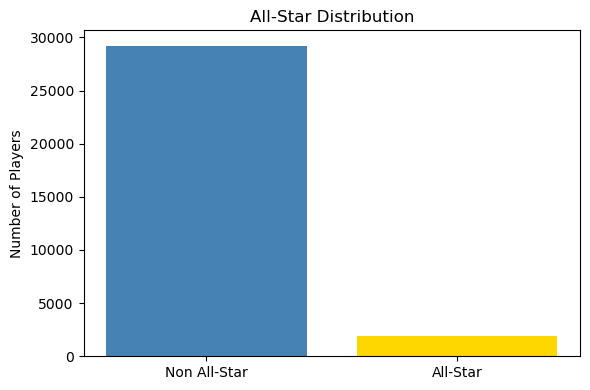

Non All-Star: 29200 (93.8%)
All-Star:     1919 (6.2%)


In [11]:
# Target distribution
counts = df[target].value_counts()
labels = ['Non All-Star', 'All-Star']

plt.figure(figsize=(6, 4))
plt.bar(labels, [counts[0], counts[1]], color=['steelblue', 'gold'])
plt.title('All-Star Distribution')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

print(f'Non All-Star: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'All-Star:     {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

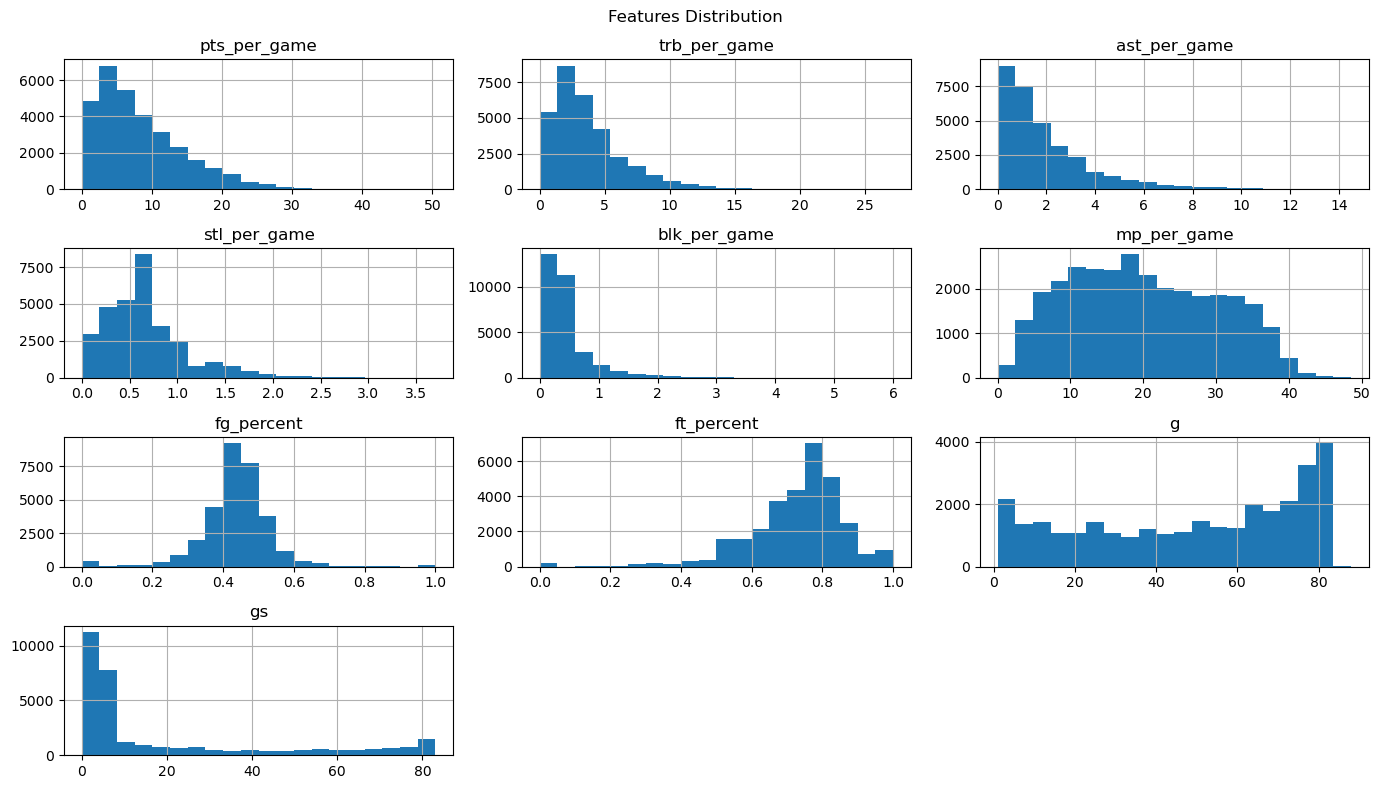

In [12]:
# Features distribution
df[features].hist(bins=20, figsize=(14, 8))
plt.suptitle('Features Distribution')
plt.tight_layout()
plt.show()

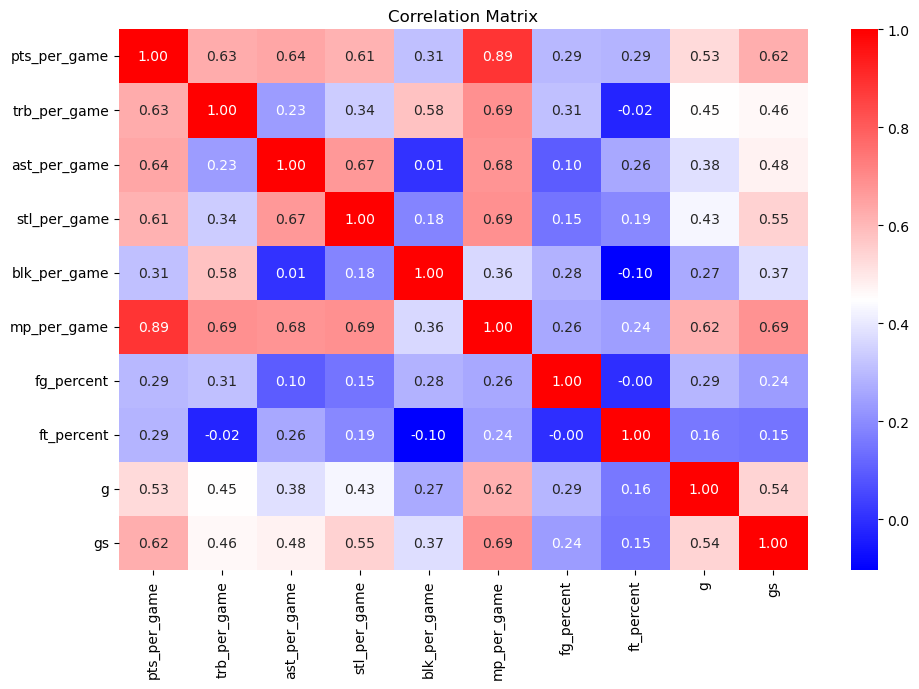

In [13]:
# Correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), cmap='bwr', annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

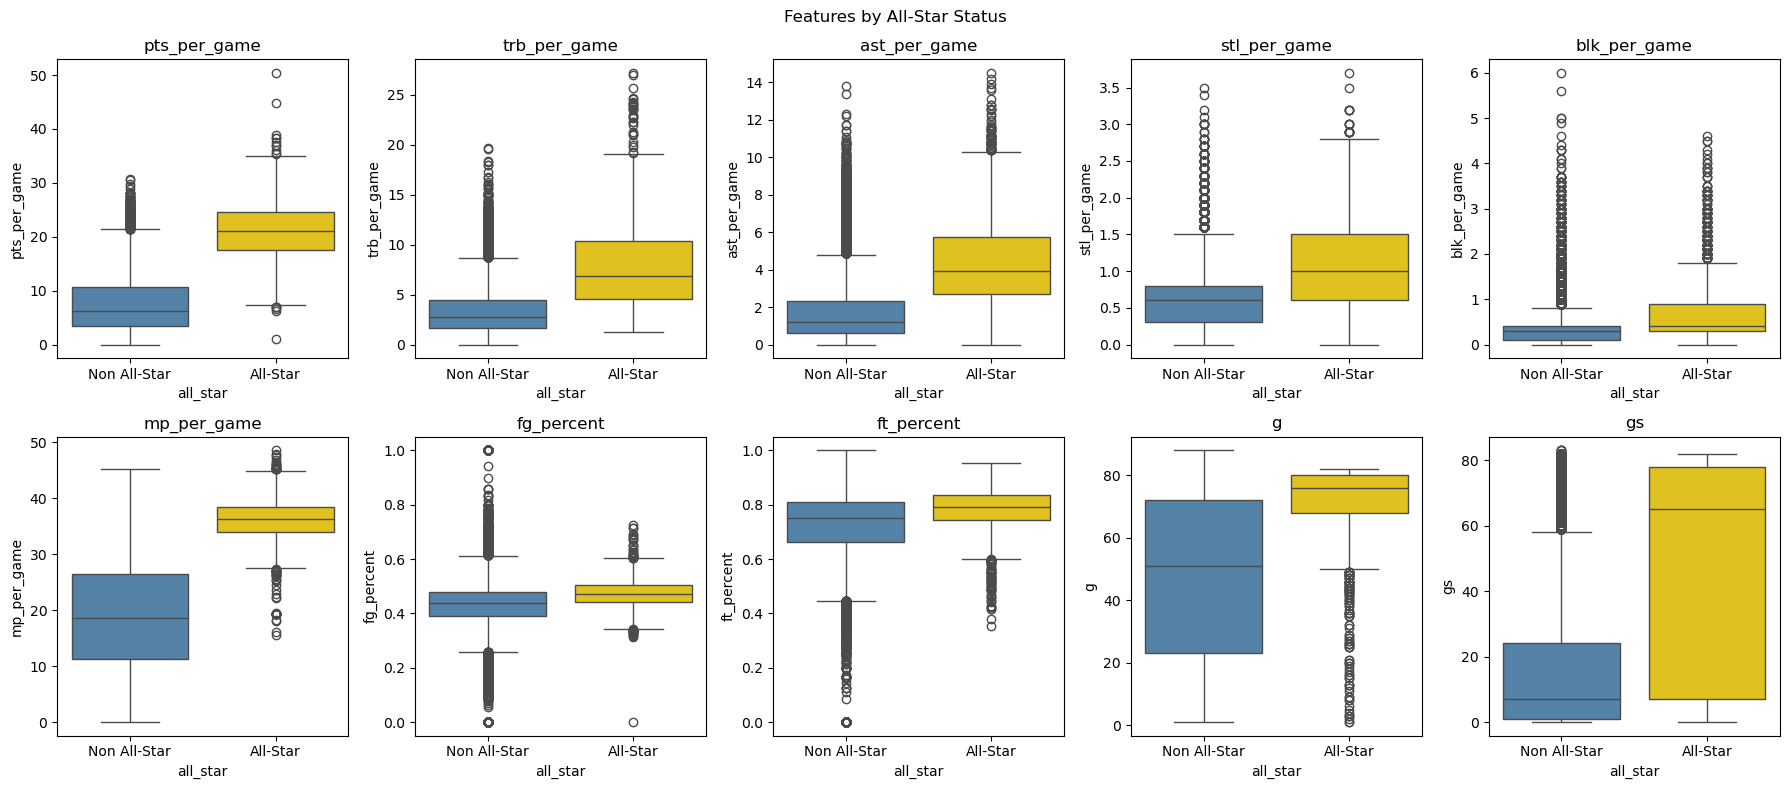

In [14]:
# Boxplots: All-Star vs Non All-Star per feature
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i], palette=['steelblue', 'gold'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Non All-Star', 'All-Star'])

plt.suptitle('Features by All-Star Status')
plt.tight_layout()
plt.show()

In [15]:
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'All-Stars in test: {y_test.sum()}')

Train: (24895, 10) | Test: (6224, 10)
All-Stars in test: 384


In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Test different hidden layer sizes
hidden_configs = [(32,), (64,), (128,), (64, 32), (128, 64)]
results_nodes = []

for config in hidden_configs:
    bpn = MLPClassifier(
        hidden_layer_sizes=config,
        activation='relu',
        learning_rate_init=0.01,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_nodes.append({'Hidden Layers': str(config), 'Accuracy (%)': round(acc * 100, 2)})
    print(f'Config {config} → Accuracy: {acc:.4f}')

df_nodes = pd.DataFrame(results_nodes)
print('\n', df_nodes)

Config (32,) → Accuracy: 0.9643
Config (64,) → Accuracy: 0.9661
Config (128,) → Accuracy: 0.9632
Config (64, 32) → Accuracy: 0.9608
Config (128, 64) → Accuracy: 0.9605

   Hidden Layers  Accuracy (%)
0         (32,)         96.43
1         (64,)         96.61
2        (128,)         96.32
3      (64, 32)         96.08
4     (128, 64)         96.05


In [17]:
# Test different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
results_lr = []

for lr in learning_rates:
    bpn = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_lr.append({'Learning Rate': lr, 'Accuracy (%)': round(acc * 100, 2)})
    print(f'LR {lr} → Accuracy: {acc:.4f}')

df_lr = pd.DataFrame(results_lr)
print('\n', df_lr)

LR 0.001 → Accuracy: 0.9621
LR 0.01 → Accuracy: 0.9608
LR 0.05 → Accuracy: 0.9645
LR 0.1 → Accuracy: 0.9539
LR 0.3 → Accuracy: 0.9383

    Learning Rate  Accuracy (%)
0          0.001         96.21
1          0.010         96.08
2          0.050         96.45
3          0.100         95.39
4          0.300         93.83


In [20]:
from sklearn.metrics import classification_report

# Best model
best_bpn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)
best_bpn.fit(X_train, y_train)
y_pred = best_bpn.predict(X_test)

print(' Classification Report ')
print(classification_report(y_test, y_pred, target_names=['Non All-Star', 'All-Star']))

# Recalling
sample = X_test[0].reshape(1, -1)
pred = best_bpn.predict(sample)[0]
actual = y_test[0]
print(f'Recalling example → Predicted: {"All-Star" if pred == 1 else "Non All-Star"}')
print(f'Actual:              {"All-Star" if actual == 1 else "Non All-Star"}')

 Classification Report 
              precision    recall  f1-score   support

Non All-Star       0.98      0.98      0.98      5840
    All-Star       0.70      0.64      0.67       384

    accuracy                           0.96      6224
   macro avg       0.84      0.81      0.82      6224
weighted avg       0.96      0.96      0.96      6224

Recalling example → Predicted: Non All-Star
Actual:              Non All-Star


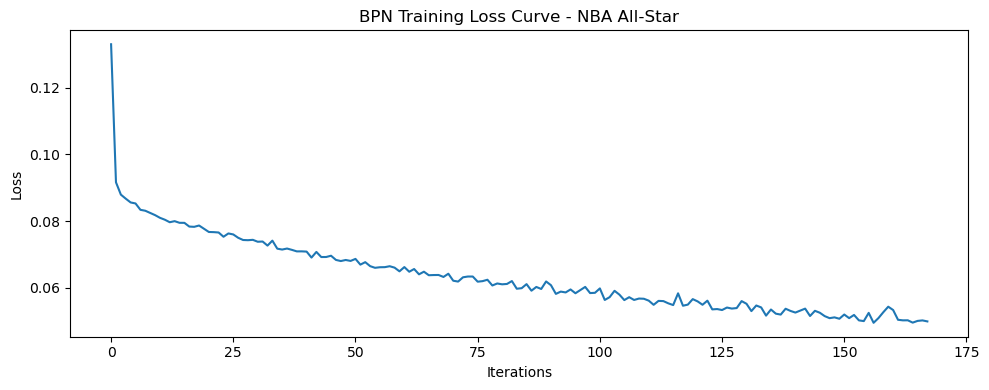

In [19]:
# Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(best_bpn.loss_curve_)
plt.title('BPN Training Loss Curve - NBA All-Star')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()